# **Data Preprocessing for Customer Analytics**

## **🧭 Business Context: Customer Analytics in Retail**

A retail company operating across Peru is looking to strengthen its marketing and customer retention strategies. To support this initiative, a survey was conducted with more than 1,000 customers from different regions.

As expected in real-world scenarios, the dataset is far from clean. It contains inconsistent text formats, missing values, potential outliers, and even variables that may not add analytical value.

In this notebook, the goal is to approach the dataset from a data analyst’s perspective: assess its quality, apply appropriate preprocessing steps, and prepare it for downstream tasks such as segmentation or predictive modeling.

**Dataset Overview**

The dataset includes customer behavior, demographics, and interaction metrics:

| Variable | Description | Type |
|----------|------------|------|
| `customer_id` | Unique identifier for each respondent | Identifier |
| `region` | Customer's region within Peru | Categorical |
| `age` | Age of the respondent | Numeric |
| `num_site_visits` | Number of website visits | Numeric |
| `num_products_viewed` | Products viewed in last session | Numeric |
| `purchase_made` | Whether a purchase occurred | Binary |
| `satisfaction_rating` | Reported satisfaction level | Ordinal |
| `customer_segment` | Segment label (e.g., Loyal, New) | Categorical |
| `preferred_channel` | Preferred communication channel | Categorical |
| `income` | Estimated monthly income (PEN) | Numeric |
| `avg_spend_per_visit` | Average spending per visit | Numeric |
| `discount_used` | Use of discount code | Binary |
| `time_on_site_min` | Time spent on site (minutes) | Numeric |
| `page_load_time_sec` | Page load time | Numeric |
| `browser` | Browser used | Categorical |
| `email_open_rate` | Email open rate (0–1) | Numeric |
| `clicked_ad` | Ad click indicator | Binary |
| `returned_product` | Whether a product was returned | Binary |
| `membership_years` | Years as a customer | Numeric |
| `zipcode` | Postal code | Categorical |
| `tracking_cookie` | Constant / likely irrelevant variable | Character |


### **Data Cleaning Strategy**

Before performing any analysis, it is important to ensure that the dataset is reliable and consistent. Rather than applying transformations blindly, the cleaning process follows a logical sequence:

1. 🧬 **Duplicate handling**  
Duplicate records can distort aggregates and model training. These should be identified and removed early in the process.

2. 🛠️ **Inconsistencies and invalid values**  
Text fields often contain variations in formatting (e.g., capitalization or trailing spaces), which should be standardized. Additionally, clearly invalid values (such as negative ages) need to be corrected or excluded to avoid introducing noise into the analysis.

3. 📈 **Outlier assessment**  
Extreme values should be explored using visual tools such as boxplots or histograms. Depending on the context, they may be capped, removed, or retained if they represent valid but rare behavior.

4. 🕳️ **Missing data treatment**  
Only after addressing the issues above is it appropriate to handle missing values. Possible strategies include:

    - **Removing observations** when missingness is minimal and random.
    - **Discarding variables** with excessive missing data.
    - **Imputing values** using methods such as mean, median, or more advanced techniques.

    The choice depends on **the extent of missingness**, its underlying **mechanism** (MCAR, MAR, MNAR), and its potential impact on the analysis.

### **1. Load the Dataset**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#../Datasets/Retail_Customer_Survey_with_Issues.csv
# Load the dataset
df = pd.read_csv(r"C:\Users\ASUS\Desktop\CICLOS - PUCP\2025-2\DATA MINING\LAB2\Retail_Customer_Survey_with_Issues.csv")
df.head()

,customer_id,region,age,num_site_visits,num_products_viewed,purchase_made,satisfaction_rating,customer_segment,preferred_channel,income,...,discount_used,time_on_site_min,page_load_time_sec,browser,email_open_rate,clicked_ad,returned_product,membership_years,zipcode,tracking_cookie
0,1,Ancash,14.0,5,11,Yes,Unsatisfied,Occasional,Email,1815.52,...,Yes,13.3,2.35,Firfox,0.68,1,Yes,4,11001,XYZ123
1,2,Piura,24.0,6,15,No,Satisfied,New,Phone,3036.29,...,Yes,4.6,2.34,Firefox,0.13,0,No,0,4001,XYZ123
2,3,piura,16.0,5,12,No,Very Unsatisfied,Occasional,In-store,3020.66,...,Yes,13.7,2.87,Firefox,0.86,1,No,5,2001,XYZ123
3,4,lima,31.0,4,7,No,Satisfied,Returning,Email,3569.71,...,Yes,5.1,4.49,Edge,0.25,1,No,5,13001,XYZ123
4,5,La Libertad,35.0,4,7,No,Unsatisfied,Loyal,Email,2352.62,...,Yes,8.1,0.90,Safari,0.36,1,No,3,13001,XYZ123


### **2. Explore the data structure**

We are going to use the `info()` statement to identify the type of variable contained in the data set, as well as the count of Non-Null values. In R, you can make the same analysis with `glimpse(df)`, but you will only see the type of variable for each of them and the first values of each column.

In [2]:
# Inspect the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          1010 non-null   int64  
 1   region               1010 non-null   object 
 2   age                  960 non-null    float64
 3   num_site_visits      1010 non-null   int64  
 4   num_products_viewed  1010 non-null   int64  
 5   purchase_made        1010 non-null   object 
 6   satisfaction_rating  960 non-null    object 
 7   customer_segment     1010 non-null   object 
 8   preferred_channel    1010 non-null   object 
 9   income               960 non-null    float64
 10  avg_spend_per_visit  958 non-null    float64
 11  discount_used        1010 non-null   object 
 12  time_on_site_min     1010 non-null   float64
 13  page_load_time_sec   1010 non-null   float64
 14  browser              1010 non-null   object 
 15  email_open_rate      1010 non-null   f

1. To get an statistical overview of each variable in the dataset, it is necessary to visualize the following differences:

- **R:** `summary(df)`
    - **Numeric variables:** It shows Minimum, 1st Quartile (25%), Median (50%), 3rd Quartile (75%), Mean and Maximum values.
    - **Categorical variables:** It shows the number of observations (Length), Class and Mode.

- **Python:**
    - **Numeric variables:** It shows the same information as R, as well as the standard desviation (std). In this case, you need to use `describe()` statement.

In [3]:
# Visualize the numeric variables:
df.describe()

,customer_id,age,num_site_visits,num_products_viewed,income,avg_spend_per_visit,time_on_site_min,page_load_time_sec,email_open_rate,clicked_ad,membership_years,zipcode
count,1010.000000,960.000000,1010.000000,1010.000000,960.000000,958.000000,1010.000000,1010.000000,1010.000000,1010.000000,1010.000000,1010.000000
mean,500.111881,35.077083,5.419802,9.874257,3021.533146,198.697140,8.037822,3.016030,0.501416,0.503960,3.023762,8944.564356
std,288.376128,10.359356,6.994689,3.025336,7066.843061,50.205175,3.871823,1.152293,0.290075,0.500232,1.720692,5076.596955
min,1.000000,-5.000000,0.000000,1.000000,-192.240000,61.430000,0.000000,0.020000,0.000000,0.000000,0.000000,2001.000000
25%,251.250000,28.000000,4.000000,8.000000,2000.307500,162.812500,5.200000,2.220000,0.250000,0.000000,2.000000,4001.000000
50%,499.500000,35.000000,5.000000,10.000000,2504.090000,197.475000,8.000000,3.000000,0.510000,1.000000,3.000000,11001.000000
75%,748.750000,42.000000,6.000000,12.000000,3057.900000,233.277500,10.500000,3.827500,0.760000,1.000000,4.000000,13001.000000
max,1000.000000,61.000000,100.000000,21.000000,99999.000000,351.450000,21.300000,6.730000,1.000000,1.000000,11.000000,15001.000000


- **Python:**
    - **Categorical and binary variables:** In addition to the non-null count, it shows the number of unique categories, as well as the most frequent category (top) and its frequency (freq). This is obtained using the `describe()` method with the `include='object'` argument.

Although you can use `include='all'`argument to display a statistical report of all types of variables, it is not recommemded, as it will show terms that do not correspond to some types of variables; for example, mean, standard desviation or median are only for numerical variables, so the report will show you null values for those situations with categorical or binary variables, which could make visualization difficult.

In [4]:
# Visualize the categorical and binary variables:
df.describe(include="object")

,region,purchase_made,satisfaction_rating,customer_segment,preferred_channel,discount_used,browser,returned_product,tracking_cookie
count,1010,1010,960,1010,1010,1010,1010,1010,1010
unique,11,2,5,4,4,2,7,2,1
top,Lima,No,Very Unsatisfied,Returning,SMS,No,Safari,Yes,XYZ123
freq,111,724,211,267,285,523,215,516,1010


2. The `skim(df)` function provides a detailed summary by grouping variables according to their type **(*numeric* = *int* + *float*, *categorical/binary* = *string*)**. Although the information is broadly similar to that obtained with `describe()`, this report additionally includes the number of missing values and their proportion, which can help assess their impact and guide data cleaning decisions.

In R, the implementation is very similar:

> ```r
> library(skimr)
> skim(df)
> ```

Moreover, this type of summary facilitates data quality assessment, making it easier to identify potential outliers, suspicious values (e.g., age < 0, income < 0), or irrelevant variables (such as `tracking_cookie`).

In [5]:
from skimpy import skim
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1010   │ │ string      │ 9     │                                                          │
│ │ Number of columns │ 21     │ │ int64       │ 6     │                                                          │
│ └───────────────────┴────────┘ │ float64     │ 6     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column         ┃ NA ┃ NA %            ┃ mean   ┃ sd     ┃ p0     ┃ p25   ┃ p50   ┃ p75   ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │ customer_id    │  0 │               0 │  500.1 │  288.4 │      1 │ 251.2 │ 499.5 │ 748.8 │   1000 │ ▇▇▇▇▇▇ │  │
│ │ age            │ 50 │ 4.9504950495049 │  35.08 │  10.36 │     -5 │    28 │    35 │    42 │     61 │  ▁▃▇▅▂ │  │
│ │                │    │             505 │        │        │        │       │       │       │        │        │  │
│ │ num_site_visit │  0 │               0 │   5.42 │  6.995 │      0 │     4 │     5 │     6 │    100 │   ▇    │  │
│ │ s              │    │                 │        │        │        │       │       │       │        │        │  │
│ │ num_products_v │  0 │               0 │  9.874 │  3.025 │      1 │     8 │    10 │    12 │     21 │  ▅▇▇▁  │  │
│ │ iewed          │    │                 │        │        │        │       │       │       │        │        │  │
│ │ income         │ 50 │ 4.9504950495049 │   3022 │   7067 │ -192.2 │  2000 │  2504 │  3058 │ 100000 │   ▇    │  │
│ │                │    │             505 │        │        │        │       │       │       │        │        │  │
│ │ avg_spend_per_ │ 52 │ 5.1485148514851 │  198.7 │  50.21 │  61.43 │ 162.8 │ 197.5 │ 233.3 │  351.4 │ ▁▅▇▇▃  │  │
│ │ visit          │    │              49 │        │        │        │       │       │       │        │        │  │
│ │ time_on_site_m │  0 │               0 │  8.038 │  3.872 │      0 │   5.2 │     8 │  10.5 │   21.3 │ ▃▆▇▅▁  │  │
│ │ in             │    │                 │        │        │        │       │       │       │        │        │  │
│ │ page_load_time │  0 │               0 │  3.016 │  1.152 │   0.02 │  2.22 │     3 │ 3.828 │   6.73 │ ▁▅▇▆▂  │  │
│ │ _sec           │    │                 │        │        │        │       │       │       │        │        │  │
│ │ email_open_rat │  0 │               0 │ 0.5014 │ 0.2901 │      0 │  0.25 │  0.51 │  0.76 │      1 │ ▇▇▆▇▇▇ │  │
│ │ e              │    │                 │        │        │        │       │       │       │        │        │  │
│ │ clicked_ad     │  0 │               0 │  0.504 │ 0.5002 │      0 │     0 │     1 │     1 │      1 │ ▇    ▇ │  │
│ │ membership_yea │  0 │               0 │  3.024 │  1.721 │      0 │     2 │     3 │     4 │     11 │  ▃▇▅▁  │  │
│ │ rs             │    │                 │        │        │        │       │       │       │        │        │  │
│ │ zipcode        │  0 │               0 │   8945 │   5077 │   2001 │  4001 │ 11000 │ 13000 │  15000 │ ▇   ▅▇ │  │
│ └────────────────┴────┴─────────────────┴────────┴────

> ❗ Note: For both types of reports displayed, some numeric variables may encode categorical or binary information (e.g., 0/1), which should be carefully reviewed in later steps.

**1. Numeric Variables Summary**

    At this stage, the assessment focuses on missing values, ranges, and potential extreme values. Further validation may be required to confirm whether extreme observations correspond to real behavior or data issues.

| Variable | Type | Data Quality Notes |
|----------|------|-------------------|
| `customer_id` | Numeric ID | ✅ No missing values. Appears to function as a unique identifier. |
| `age` | Numeric | ❌ Minimum value below zero and presence of missing values → requires cleaning and imputation. |
| `num_site_visits` | Numeric | ⚠️ High maximum value detected → potential outlier, requires further inspection. |
| `num_products_viewed` | Numeric | ✅ Values fall within a reasonable range based on current summary. |
| `income` | Numeric | ❌ Presence of missing values and extreme minimum/maximum values → requires validation and possible treatment (e.g., filtering or capping). |
| `avg_spend_per_visit` | Numeric | ⚠️ Moderate number of missing values → imputation strategy should be considered. |
| `time_on_site_min` | Numeric | ✅ No immediate anomalies detected in range or missingness. |
| `page_load_time_sec` | Numeric | ✅ Values appear consistent with expected behavior. |
| `email_open_rate` | Numeric (0–1) | ✅ Values fall within expected bounds. |
| `clicked_ad` | Binary (0/1) | ✅ Proper encoding and no missing values observed. |
| `membership_years` | Numeric | ✅ Values appear within a plausible range. |

**2. Categorical Variables Summary**

    At this stage, the assessment is limited to structural properties such as cardinality, missingness, and dominant categories. A more detailed inspection of raw values will be required to confirm potential inconsistencies.

| Variable | Type | Data Quality Notes |
|----------|------|-------------------|
| `region` | Categorical | ⚠️ Multiple unique values detected. This may indicate potential inconsistencies in formatting (e.g., casing or spacing), which should be verified in later steps. |
| `purchase_made` | Binary/Categorical | ⚠️ Limited number of categories observed. However, representation inconsistencies cannot be ruled out without further inspection. |
| `satisfaction_rating` | Ordinal | ⚠️ Presence of missing or empty values suggested by summary statistics → requires validation. |
| `customer_segment` | Categorical | ✅ Number of categories appears consistent and manageable. |
| `preferred_channel` | Categorical | ✅ No immediate issues detected, though consistency checks are recommended. |
| `browser` | Categorical | ⚠️ Several unique values detected → possible inconsistencies should be explored in subsequent analysis. |
| `discount_used` | Binary/Categorical | ⚠️ Expected binary structure, but encoding consistency should be confirmed. |
| `returned_product` | Binary/Categorical | ⚠️ Similar to other binary fields, representation consistency should be validated. |
| `zipcode` | Categorical/Numeric | ✅ Appears structurally consistent. |
| `tracking_cookie` | Constant | ❌ Single unique value → not informative and should be removed. |

> ⚠️ Note: Variables such as `purchase_made`, `discount_used`, and `returned_product` show two unique values in the current summary output (`describe()`), which is consistent with a binary structure.
>
> However, this does not fully guarantee the absence of representation inconsistencies (e.g., differences in capitalization, spacing, or encoding). A more detailed value-level inspection will be required in later steps to confirm data consistency.
>
> For the remaining categorical variables, no definitive conclusions about potential inconsistencies can be drawn at this stage, as the current analysis is limited to aggregated summaries. Therefore, any potential issues (such as inconsistent labels or typographical errors) will be explicitly validated during the subsequent data cleaning phase.

### **3. Remove Duplicates and Handle Inconsistencies**
#### **3.1 Remove duplicates**
For this stage, we must ensure that **each customer is represented only once** in the dataset, using the `customer_id` variable as the identifier. To do this, duplicate records that could distort the actual number of customers and bias subsequent analyses are identified and removed.

In [6]:
print(f"Number of duplicated rows:\n {df.duplicated().sum()}")

Number of duplicated rows:
 9


In R, the `duplicate()` function allows you to identify repeated rows within a data set; however, it only marks subsequent occurrences as duplicates, excluding the first occurrence.

> ```r
> df %>% 
>   filter(duplicated(.))
> ```

To view all rows involved in duplicates (including the first occurrence), additional steps are needed, such as grouping and filtering by frequency:

> ```r
> df %>%
>   group_by_all() %>%
>   filter(n() > 1) %>%
>   arrange(customer_id)
> ```

In Python, however, the `duplicated()` method can be used directly as a filter, and the `keep=False` argument allows you to show all occurrences of duplicate values, including the first one.

In [7]:
# Show duplicated rows
df[df.duplicated()].sort_values('customer_id')

,customer_id,region,age,num_site_visits,num_products_viewed,purchase_made,satisfaction_rating,customer_segment,preferred_channel,income,...,discount_used,time_on_site_min,page_load_time_sec,browser,email_open_rate,clicked_ad,returned_product,membership_years,zipcode,tracking_cookie
1005,15,lima,38.0,5,9,No,Unsatisfied,Loyal,Email,3087.33,...,Yes,1.2,3.23,Safari,0.53,1,No,6,11001,XYZ123
1003,176,Junin,22.0,6,7,No,Unsatisfied,Returning,SMS,2621.76,...,Yes,8.8,3.03,Edge,0.68,0,Yes,1,11001,XYZ123
1001,321,Arequipa,40.0,4,9,Yes,Very Unsatisfied,Returning,SMS,2413.47,...,No,5.0,3.42,Chrome,0.91,1,Yes,2,2001,XYZ123
1004,357,Lima,36.0,4,13,Yes,Neutral,Occasional,Phone,4058.53,...,No,12.7,3.80,Edge,0.76,1,No,1,15001,XYZ123
1000,492,Cusco,46.0,6,6,No,Neutral,Occasional,SMS,2169.39,...,No,7.3,4.63,IE,0.48,1,No,2,15001,XYZ123
1009,499,CUSCO,31.0,5,9,No,Neutral,Occasional,SMS,1697.05,...,No,5.7,3.99,Firefox,0.38,1,No,2,13001,XYZ123
1006,555,LIMA,46.0,5,10,No,Very Unsatisfied,Occasional,SMS,2891.50,...,No,2.9,2.42,Safari,0.13,1,No,3,15001,XYZ123
1008,667,LIMA,34.0,6,10,No,Very Satisfied,New,Phone,2915.10,...,No,7.3,4.11,IE,0.79,0,No,7,11001,XYZ123
1007,691,La Libertad,51.0,5,9,No,Satisfied,Loyal,In-store,2066.34,...,No,13.9,0.72,Edge,0.08,0,Yes,2,13001,XYZ123


In [8]:
# View all duplicate rows including their first occurrences
df[df.duplicated(keep=False)].sort_values("customer_id")

,customer_id,region,age,num_site_visits,num_products_viewed,purchase_made,satisfaction_rating,customer_segment,preferred_channel,income,...,discount_used,time_on_site_min,page_load_time_sec,browser,email_open_rate,clicked_ad,returned_product,membership_years,zipcode,tracking_cookie
14,15,lima,38.0,5,9,No,Unsatisfied,Loyal,Email,3087.33,...,Yes,1.2,3.23,Safari,0.53,1,No,6,11001,XYZ123
1005,15,lima,38.0,5,9,No,Unsatisfied,Loyal,Email,3087.33,...,Yes,1.2,3.23,Safari,0.53,1,No,6,11001,XYZ123
1003,176,Junin,22.0,6,7,No,Unsatisfied,Returning,SMS,2621.76,...,Yes,8.8,3.03,Edge,0.68,0,Yes,1,11001,XYZ123
175,176,Junin,22.0,6,7,No,Unsatisfied,Returning,SMS,2621.76,...,Yes,8.8,3.03,Edge,0.68,0,Yes,1,11001,XYZ123
320,321,Arequipa,40.0,4,9,Yes,Very Unsatisfied,Returning,SMS,2413.47,...,No,5.0,3.42,Chrome,0.91,1,Yes,2,2001,XYZ123
1001,321,Arequipa,40.0,4,9,Yes,Very Unsatisfied,Returning,SMS,2413.47,...,No,5.0,3.42,Chrome,0.91,1,Yes,2,2001,XYZ123
1004,357,Lima,36.0,4,13,Yes,Neutral,Occasional,Phone,4058.53,...,No,12.7,3.80,Edge,0.76,1,No,1,15001,XYZ123
356,357,Lima,36.0,4,13,Yes,Neutral,Occasional,Phone,4058.53,...,No,12.7,3.80,Edge,0.76,1,No,1,15001,XYZ123
1000,492,Cusco,46.0,6,6,No,Neutral,Occasional,SMS,2169.39,...,No,7.3,4.63,IE,0.48,1,No,2,15001,XYZ123
491,492,Cusco,46.0,6,6,No,Neutral,Occasional,SMS,2169.39,...,No,7.3,4.63,IE,0.48,1,No,2,15001,XYZ123


If identical rows are detected, they can be removed from the dataset.

In [9]:
# Compare the initial number of records with the following
print(f"Number of rows (before): {len(df)}")

# Remove all complete duplicates and check the records
df = df.drop_duplicates()
print(f"Number of rows (after): {len(df)}")

Number of rows (before): 1010
Number of rows (after): 1001


The reasons for these duplicate rows could be that the customer completed the survey twice in the same way. For this type of situations, you should carefully review the dataset and ensure that, for the same `customer_id`, the remaining columns have different values (the customer may have updated some relevant information, so you should perform an analysis with additional context).

#### **3.2 Handle inconsistencies**
Focusing on the categorical and binary variables, the goal for this part is to find non-standardized values that could distort the actual categories and the frequency of each one. Among the possible errors found are differences due to the use of capitalization (`"Cusco"` vs `"CUSCO"`) or formatting errors (`"Chorme"` vs `"Chrome"`).

**Step 1: Analyze the structure of the variables**

To visualize the unique values per selected variable, we can use the `unique()` method to view the included categories.

In [10]:
# Unique values for the "region" variable
df['region'].unique()

array(['Ancash', 'Piura', 'piura ', 'lima', 'La Libertad', 'CUSCO',
       'Arequipa', 'Junin', 'Cusco', 'Lima', 'LIMA '], dtype=object)

In R and, in case you have a lot of categorical and binary variables and you want to view them without consulting for each one, you can run the next code:

>```r
>sapply(df[, sapply(df, is.character)], unique)
>```

In Python, the approach differs slightly and can be broken down into the following steps:

- `df.select_dtypes(include=['object']).columns` identifies columns with object (string) data type.
- A `for` loop iterates over these columns.
- For each column, `df[col].unique()` retrieves the distinct values, which are then printed alongside the column name.

In [11]:
# View the unique values for each character variable
for col in df.select_dtypes(include=['object']).columns:
    print(f"\n{col}", df[col].unique(), sep="\n")


region
['Ancash' 'Piura' 'piura ' 'lima' 'La Libertad' 'CUSCO' 'Arequipa' 'Junin'
 'Cusco' 'Lima' 'LIMA ']

purchase_made
['Yes' 'No']

satisfaction_rating
['Unsatisfied' 'Satisfied' 'Very Unsatisfied' 'Neutral' 'Very Satisfied'
 nan]

customer_segment
['Occasional' 'New' 'Returning' 'Loyal']

preferred_channel
['Email' 'Phone' 'In-store' 'SMS']

discount_used
['Yes' 'No']

browser
['Firfox' 'Firefox' 'Edge' 'Safari' 'Chrome' 'IE' 'Chorme']

returned_product
['Yes' 'No']

tracking_cookie
['XYZ123']


**Inconsistencies detected:**

| Variable | Visible Problems |
|----------|------------------|
| `region` | There are categories that are written differently and with additional spaces (`"Lima"` vs `"LIMA "`) which leads to an increase in the number of unique values when in reality this is not the case. |
| `satisfaction_rating` | In R, empty strings (`""`) are preserved as valid values. In contrast, when importing data in pandas, empty fields are typically interpreted as missing values (`NaN`). |
| `browser` | Typographical errors are shown for the same categories (`"Firfox"` vs `"Firefox"`). |
| `tracking_cookie` | It only demonstrates a single value (`"XYZ123"`) and does not present relevant information. |

**Step 2: Proceed with the cleaning**

In [12]:
# Delete irrelevant column
df.drop('tracking_cookie', axis=1, inplace=True)

We clean **selected binary and categorical variables** by removing extra whitespace, standardizing text to lowercase, and converting empty strings into missing values.

In [13]:
# Step1: Clean binary variables and the satisfaction rating column

# Define a list with the names of binary or categorical variables
binary_vars = ["purchase_made", "discount_used", "returned_product", "satisfaction_rating"]

# Change "" to NA and standarize to lowercase
df[binary_vars] = (df[binary_vars].apply(lambda s: s.str.strip().str.lower()).replace("", np.nan))
df[binary_vars].apply(pd.unique)

purchase_made                                                  [yes, no]
discount_used                                                  [yes, no]
returned_product                                               [yes, no]
satisfaction_rating    [unsatisfied, satisfied, very unsatisfied, neu...
dtype: object

Except for the `"browser"` and `"region"` columns, the rest of the variables do not present inconsistencies, so we will only focus on the two mentioned to perform the standardization.

In [14]:
# Step2: View the current status of the "region" and "browser" column
print("Initial values for region: ", df['region'].unique())
print(df.groupby('region').size())

print("Initial values for browser: ", df["browser"].unique())
print(df.groupby('browser').size())

Initial values for region:  ['Ancash' 'Piura' 'piura ' 'lima' 'La Libertad' 'CUSCO' 'Arequipa' 'Junin'
 'Cusco' 'Lima' 'LIMA ']
region
Ancash          86
Arequipa       103
CUSCO          100
Cusco           79
Junin           87
LIMA            88
La Libertad    102
Lima           110
Piura           84
lima            91
piura           71
dtype: int64
Initial values for browser:  ['Firfox' 'Firefox' 'Edge' 'Safari' 'Chrome' 'IE' 'Chorme']
browser
Chorme      12
Chrome     176
Edge       188
Firefox    194
Firfox       8
IE         210
Safari     213
dtype: int64


- **For `region`:** The column has issues related to capitalization and extra spaces.

In [15]:
# All letters to lowercase and delete the unnecessary spaces:
df['region'] = df['region'].str.strip().str.lower()

# Capitalize the first letter of each value; then fix specific cases that require custom capitalization
df['region'] = df['region'].str.capitalize()
df['region'] = df['region'].replace({
        'La libertad': 'La Libertad'
})
print(df.groupby('region').size())

region
Ancash          86
Arequipa       103
Cusco          179
Junin           87
La Libertad    102
Lima           289
Piura          155
dtype: int64


- **For `browser`:** The column only shows problems with proper spelling.

In [16]:
# Standarize the variable 'browser':
df['browser'] = df['browser'].replace({
    'Firfox': 'Firefox',
    'Chorme': 'Chrome'
})
print(df.groupby('browser').size())

browser
Chrome     188
Edge       188
Firefox    202
IE         210
Safari     213
dtype: int64


**Recommendation: Convert variables with characters into categories**

Unlike R, where **converting to factors is often required for models and plots to behave correctly**, Python's libraries generally **handle string columns directly**. However, converting to category dtype in pandas is still recommended for memory efficiency and to make categorical intent explicit, especially in large datasets or when controlling plot ordering. That said, if you plan to build a model with this dataset, the conversion may become necessary **depending on the algorithm and library used**.

In R, the conversion of variables is done as follows:

>```r
>df <- df %>%
>  mutate(across(where(is.character), as.factor))
>```

In Python, you need to filter the required columns and then perform the conversion.

In [17]:
# Convert selected variables to category:
var_selected = df.select_dtypes(include=['object'])
df[var_selected.columns] = var_selected.astype("category")

# Look at the data types
df.dtypes

customer_id               int64
region                 category
age                     float64
num_site_visits           int64
num_products_viewed       int64
purchase_made          category
satisfaction_rating    category
customer_segment       category
preferred_channel      category
income                  float64
avg_spend_per_visit     float64
discount_used          category
time_on_site_min        float64
page_load_time_sec      float64
browser                category
email_open_rate         float64
clicked_ad                int64
returned_product       category
membership_years          int64
zipcode                   int64
dtype: object

### **4. Handle Outliers and Invalid Entries**

In [18]:
# Visualize numeric variables
df.describe()

,customer_id,age,num_site_visits,num_products_viewed,income,avg_spend_per_visit,time_on_site_min,page_load_time_sec,email_open_rate,clicked_ad,membership_years,zipcode
count,1001.000000,951.000000,1001.000000,1001.000000,951.000000,951.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,500.839161,35.047319,5.422577,9.881119,3024.975131,198.633270,8.045355,3.013826,0.501189,0.502498,3.024975,8919.081918
std,288.874359,10.372071,7.025685,3.032961,7099.864950,50.331034,3.870434,1.152616,0.290208,0.500244,1.717666,5079.299432
min,1.000000,-5.000000,0.000000,1.000000,-192.240000,61.430000,0.000000,0.020000,0.000000,0.000000,0.000000,2001.000000
25%,251.000000,28.000000,3.000000,8.000000,1998.015000,162.425000,5.200000,2.220000,0.250000,0.000000,2.000000,4001.000000
50%,501.000000,35.000000,5.000000,10.000000,2504.000000,197.620000,8.100000,2.990000,0.510000,1.000000,3.000000,11001.000000
75%,751.000000,42.000000,6.000000,12.000000,3058.240000,233.235000,10.500000,3.820000,0.760000,1.000000,4.000000,13001.000000
max,1000.000000,61.000000,100.000000,21.000000,99999.000000,351.450000,21.300000,6.730000,1.000000,1.000000,11.000000,15001.000000


**1. `age`:** We observed invalid ages because they were negative (`age` = -5), so we proceeded to invalidate them and assign them as null values. In R, you can use `ifelse()` function to remove invalid age entries and `hist()` to plot the histogram.

>```r
>df$age <- ifelse(df$age < 0 | df$age > 100, NA, df$age)
>hist(df$age)
>```

In Python, you can use `where()` function accompained with `between()` method to make the apply the first step and `histplot()` from **seaborn** to visualize the graphic.

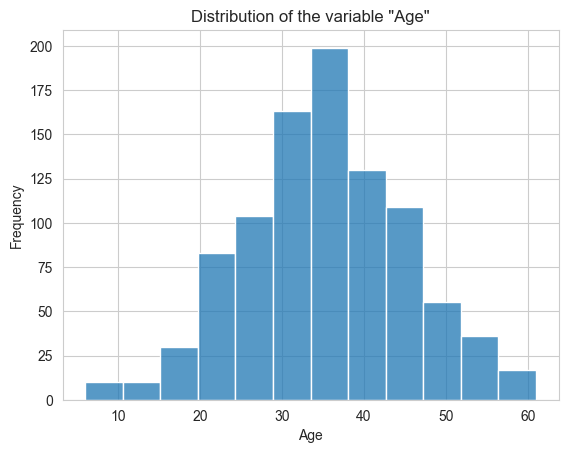

In [19]:
# Remove invalid age entries
df['age'] = df['age'].where(df['age'].between(0,100), np.nan)

# Histogram for 'Age'
sns.set_style("whitegrid")
sns.histplot(df['age'].dropna(), bins=12)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of the variable "Age"')
plt.show()

**2. `income`**

In [20]:
# Statistical report:
df['income'].describe()

count      951.000000
mean      3024.975131
std       7099.864950
min       -192.240000
25%       1998.015000
50%       2504.000000
75%       3058.240000
max      99999.000000
Name: income, dtype: float64

If you look at the maximum value, it's too far from the average. It will be clearer when you create a graphics

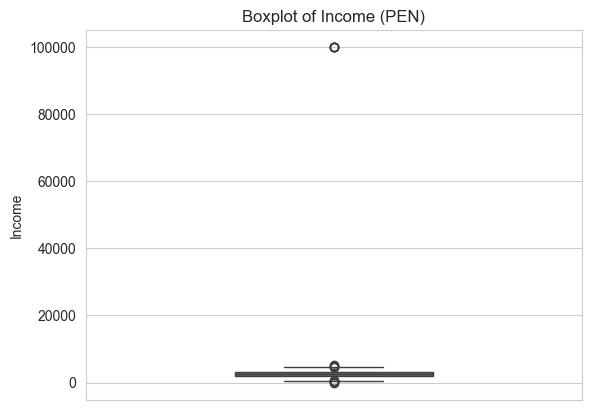

In [21]:
# Boxplot for 'Income'
sns.boxplot(df['income'].dropna(), width=0.4)
plt.ylabel('Income')
plt.title('Boxplot of Income (PEN)')
plt.show()

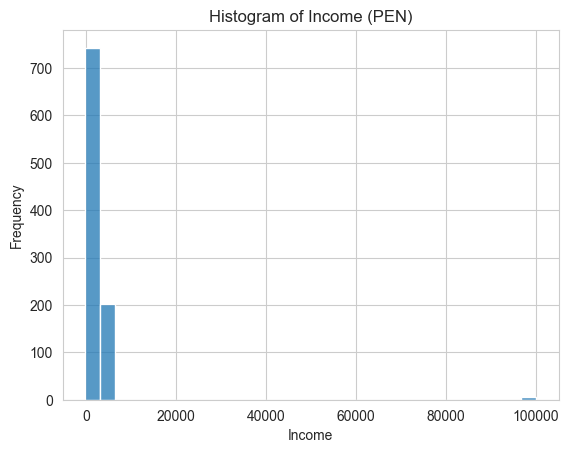

In [22]:
# Histogram for 'Income'
sns.histplot(df['income'].dropna(), bins=30)
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.title('Histogram of Income (PEN)')
plt.show()

After analyzing the variable `'Income'`, we can see that it exhibits unreliable values ​​at its extremes. On the one hand, the minimum value is less than 0 (e.g., -192), and the maximum value is extremely large (e.g., 99,999).

Additionally, when the mean of a variable is higher than the median, we can conclude that **there is right-skewness**, which implies that the distribution is skewed to the right by the presence of high extreme values ​​(outliers).

> ⁉️ Beyond visualization and outlier detection, skewness has direct implications for modeling: it may require transformations (log, Box-Cox), distort scaling by extreme values, and affect the performance of distribution-sensitive models, such as distance-based models.

In [23]:
# Number of values ​​above a normal limit (e.g., 10000 PEN)
print("Number of records: ", (df['income'] > 10000).sum())

Number of records:  5


**- Convert unrealistic values ​​to null**

In [24]:
# If 'income' is less than 0 then the value is not real
df['income'] = np.where(df['income'] <= 0, np.nan, df['income'])

**- IQR Method to Cap Extreme High Values**

The IQR (Interquartile Range) method is a robust technique for detecting and handling outliers. It defines an upper bound as Q3 + 1.5 × IQR — any value exceeding this threshold is considered extreme. Rather than dropping these records, a **capping strategy** is applied: outliers are replaced with the upper bound value. This preserves all observations in the dataset while preventing extreme values from distorting the analysis or any subsequent model.

In [25]:
# Calculate IQR bounds
q1_income = df['income'].quantile(0.25)
q3_income = df['income'].quantile(0.75)
iqr_income = q3_income - q1_income

# Define upper bound
upper_bound_income = q3_income + 1.5*iqr_income

# Cap income at upper bound
df['income_capped'] = np.where(df['income'] > upper_bound_income, upper_bound_income, df['income'])

**- Visualize After Capping**

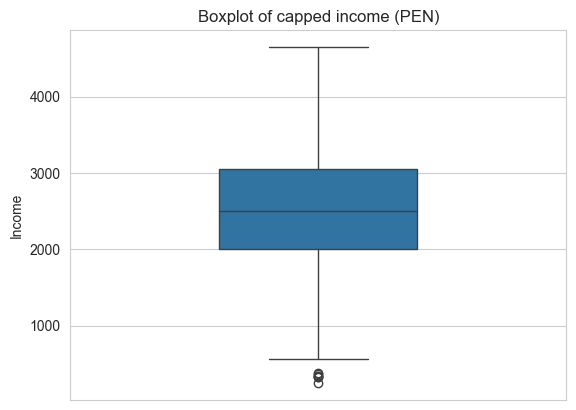

In [26]:
# Visualize using boxplot
sns.boxplot(df['income_capped'].dropna(), width=0.4)
plt.ylabel('Income')
plt.title('Boxplot of capped income (PEN)')
plt.show()

By limiting extreme values, we reduced the **skewness** that could affect future models. Furthermore, we achieved a more realistic distribution for the variable in relation to the customer.

**3. `num_site_visits`**

In [27]:
# Summary statistics
df['num_site_visits'].describe()

count    1001.000000
mean        5.422577
std         7.025685
min         0.000000
25%         3.000000
50%         5.000000
75%         6.000000
max       100.000000
Name: num_site_visits, dtype: float64

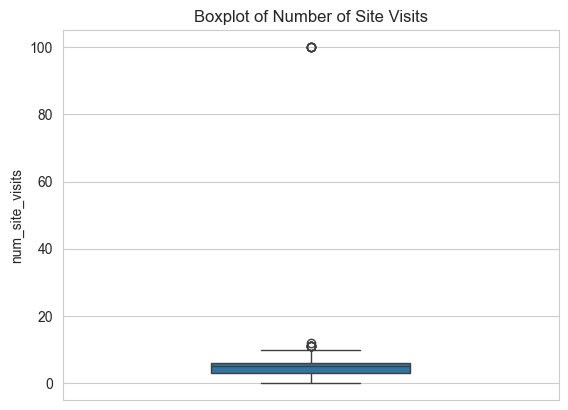

In [28]:
# Boxplot
sns.boxplot(df['num_site_visits'].dropna(), width=0.4)
plt.title('Boxplot of Number of Site Visits')
plt.show()

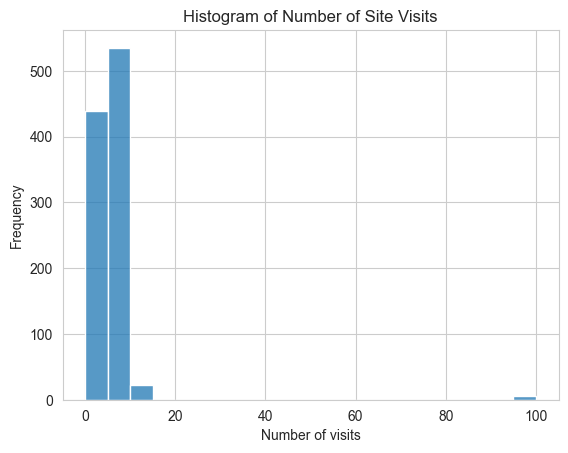

In [29]:
# Histogram
sns.histplot(df['num_site_visits'].dropna(), bins=20)
plt.xlabel('Number of visits')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Site Visits')
plt.show()

In both the statistical report and the two graphs produced, we observed unrealistic values, specifically, when we detected that there is a record with a number of visits equal to 100.

In [30]:
# Review how many records exceed the acceptable threshold (e.g. 50 visits per session)
print("Number of records: ", (df['num_site_visits']>50).sum())

Number of records:  5


Since there are few records with a very extreme value, we can consider them as anomalies and convert them to null values.

**- Convert unrealistic values ​​to null**

In [31]:
# If 'num_site_visits' is more than 50 then the value is not real
df['num_site_visits'] = np.where(df['num_site_visits'] > 50, np.nan, df['num_site_visits'])

**- IQR Method to Cap Extreme High Values**

In [32]:
# Calculate IQR bounds
q1 = df['num_site_visits'].quantile(0.25)
q3 = df['num_site_visits'].quantile(0.75)
iqr = q3 - q1

# Define upper bound
upper_bound = q3 + 1.5*q1

# Cap 'num_site_visits' at upper bound
df['num_site_visits_capped'] = np.where(df['num_site_visits'] > upper_bound, upper_bound, df['num_site_visits'])

**- Visualize After Capping**

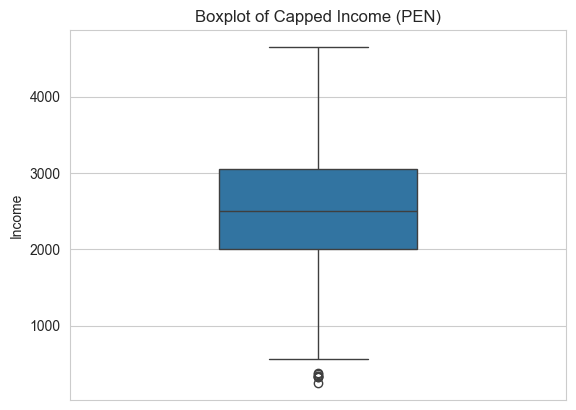

In [33]:
# Boxplot after Capping
sns.boxplot(df['income_capped'].dropna(), width=0.4)
plt.title("Boxplot of Capped Income (PEN)")
plt.ylabel("Income")
plt.show()

> 🧠 **Reminder:**
>
>For this case study, it's more convenient to convert outliers to null values, as **they exhibit unrealistic behavior**. If the outlier variation is not very large or if the values ​​are plausible, **capping** can be used to avoid losing rows.

### **5. Missing Values**

Once the previous steps have been completed, we can now have a more precise number of missing values ​​and, based on the analysis of these, we can determine whether it is necessary to ignore them, eliminate variables, or perform imputations.

#### **5.1 Use summary statistics to assess missing values**

Check the number of missing values ​​for each variable.

In [34]:
# Number of missing values by variable
df.isna().sum()

customer_id                0
region                     0
age                       55
num_site_visits            5
num_products_viewed        0
purchase_made              0
satisfaction_rating       50
customer_segment           0
preferred_channel          0
income                    51
avg_spend_per_visit       50
discount_used              0
time_on_site_min           0
page_load_time_sec         0
browser                    0
email_open_rate            0
clicked_ad                 0
returned_product           0
membership_years           0
zipcode                    0
income_capped             51
num_site_visits_capped     5
dtype: int64

Just like the first time, we performed a detailed report with `skim(df)`.

In [36]:
# Summarize dataset
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 1001   │ │ float64     │ 9     │ │ region                │                                │
│ │ Number of columns │ 22     │ │ category    │ 8     │ │ purchase_made         │                                │
│ └───────────────────┴────────┘ │ int64       │ 5     │ │ satisfaction_rating   │                                │
│                                └─────────────┴───────┘ │ customer_segment      │                                │
│                                                        │ preferred_channel     │                                │
│                                                        │ discount_used         │                                │
│                                                        │ browser               │                                │
│                                                        │ returned_product      │                                │
│                                                        └───────────────────────┘                                │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column          ┃ NA ┃ NA %            ┃ mean   ┃ sd     ┃ p0    ┃ p25   ┃ p50   ┃ p75   ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │ customer_id     │  0 │               0 │  500.8 │  288.9 │     1 │   251 │   501 │   751 │   1000 │ ▇▇▇▇▇▇ │  │
│ │ age             │ 55 │ 5.4945054945054 │  35.26 │  9.981 │     6 │ 28.25 │    35 │    42 │     61 │  ▃▆▇▃▁ │  │
│ │                 │    │             945 │        │        │       │       │       │       │        │        │  │
│ │ num_site_visits │  5 │ 0.4995004995004 │  4.948 │  2.106 │     0 │     3 │     5 │     6 │     12 │ ▁▅▇▅▂  │  │
│ │                 │    │             995 │        │        │       │       │       │       │        │        │  │
│ │ num_products_vi │  0 │               0 │  9.881 │  3.033 │     1 │     8 │    10 │    12 │     21 │  ▅▇▇▁  │  │
│ │ ewed            │    │                 │        │        │       │       │       │       │        │        │  │
│ │ income          │ 51 │ 5.0949050949050 │   3028 │   7103 │ 246.7 │  1999 │  2504 │  3059 │ 100000 │   ▇    │  │
│ │                 │    │              95 │        │        │       │       │       │       │        │        │  │
│ │ avg_spend_per_v │ 50 │ 4.9950049950049 │  198.6 │  50.33 │ 61.43 │ 162.4 │ 197.6 │ 233.2 │  351.4 │ ▁▅▇▇▃  │  │
│ │ isit            │    │              95 │        │        │       │       │       │       │        │        │  │
│ │ time_on_site_mi │  0 │               0 │  8.045 │   3.87 │     0 │   5.2 │   8.1 │  10.5 │   21.3 │ ▃▆▇▅▁  │  │
│ │ n               │    │                 │        │        │       │       │       │       │        │        │  │
│ │ page_load_time_ │  0 │               0 │  3.014 │  1.153 │  0.02 │  2.22 │  2.99 │  3.82 │   6.73 │ ▁▅▇▆▂  │  │
│ │ sec             │    │                 │        │        │       │       │       │       │        │        │  │
│ │ email_open_rate │  0 │               0 │ 0.5012 │ 0.2902 │     0 │  0.25 │  0.51 │  0.76 │      1 │ ▇▇▆▇▇▇ │  │
│ │ clicked_ad      │  0 │               0 │ 0.5025 │ 0.

#### **5.2 Compute the Number of Missing Values**

To visualize the number of missing values ​​per row, you can use the following code from the `naniar` package in R:

>```r
>naniar::miss_case_table(df)
>```

In Python, this information can be obtained by summing the number of missing values ​​per row and then counting their frequencies (`df.isna().sum(axis=1).value_counts()`).

However, to improve the visualization of the result and add the percentage corresponding to each category of missing values, a dataframe with descriptive names and an additional percentage column can be constructed.

In [ ]:
# Missing values by row
na1 = df.isna().sum(axis=1).value_counts().reset_index()
na1.columns = ["n_miss_in_case", "n_cases"]
na1["pct_cases"] = round(na1["n_cases"]/len(df) * 100, 2)

na1

,n_miss_in_case,n_cases,pct_cases
0,0,813,81.22
1,1,118,11.79
2,2,61,6.09
3,3,9,0.90


**Interpretation**

- It is observed that the majority of the rows are complete (**81.22%**), that is, they do not have missing values. 
- The maximum number of missing values ​​per row is equal to 3, representing less than 1% of the total observations.

Since the proportion of missing data per row is relatively low, it is possible to proceed with imputation of priority variables without needing to delete rows from the data set.

In R, `miss_var_summary()` from the naniar package can be used to display the variables in the data set along with the number and proportion of missing values corresponding to each:

>```r
>naniar::miss_var_summary(df)
>```

In Python, there is no equivalent function that generates this summary immediately. To obtain a similar result, it is necessary to build a table that contains the names of the variables, the number of missing values ​​and the percentage they represent within each column.

In [70]:
# Missing values by variable
pd.DataFrame({
    "variable": df.columns,
    "n_miss": df.isna().sum(),
    "pct_miss (%)": (df.isna().mean()*100).round(2)
}).sort_values("pct_miss (%)", ascending=False).reset_index(drop=True)

,variable,n_miss,pct_miss (%)
0,age,55,5.49
1,income,51,5.09
2,income_capped,51,5.09
3,avg_spend_per_visit,50,5.00
4,satisfaction_rating,50,5.00
5,num_site_visits,5,0.50
6,num_site_visits_capped,5,0.50
7,num_products_viewed,0,0.00
8,customer_id,0,0.00
9,region,0,0.00


**Conclusions:**

Only the variables `age`, `income` (along with its `income_capped` version), `avg_spend_per_visit` and `satisfaction_rating` present proportions of missing values ​​close to 5–6%. Since this percentage is relatively low and does not exceed higher thresholds commonly considered problematic (e.g., 30–40%), these variables can be treated using imputation techniques.

In the rest of the variables, no missing values ​​are observed, so they do not require additional treatment processes.

#### **5.3 Missingness by Groups**

To determine an appropriate imputation strategy, it is necessary to evaluate whether missing values ​​occur randomly or whether they are associated with other variables in the data set.

- **Step 1: Visualize Missingness by Group**

    In R, the naniar package can again be used to analyze patterns of missing values by customer segment:

    >```r
    >naniar::gg_miss_fct(df, fct = customer_segment)
    >```

    In Python, there is no equivalent function that generates this display. To obtain similar information, the analysis can be reconstructed in two stages. First, observations are grouped according to customer segment and the percentage of missing values ​​is calculated for each variable within each group.

In [76]:
# Visualize missingness by group
miss_pct = df.isna().groupby(df["customer_segment"], observed=False).mean().mul(100).T.sort_index(ascending=False)
miss_pct

customer_segment,Loyal,New,Occasional,Returning
zipcode,0.000000,0.000000,0.000000,0.000000
time_on_site_min,0.000000,0.000000,0.000000,0.000000
satisfaction_rating,6.048387,3.629032,6.666667,3.773585
returned_product,0.000000,0.000000,0.000000,0.000000
region,0.000000,0.000000,0.000000,0.000000
purchase_made,0.000000,0.000000,0.000000,0.000000
preferred_channel,0.000000,0.000000,0.000000,0.000000
page_load_time_sec,0.000000,0.000000,0.000000,0.000000
num_site_visits_capped,0.403226,0.806452,0.833333,0.000000
num_site_visits,0.403226,0.806452,0.833333,0.000000


From the table above, we generated a heat map to visualize the proportion of missing values ​​by variable and customer segment. Inside the `heatmap()` function, we use the `cmap='viridis'` argument to define the color palette and `cbar_kws` to customize the color bar associated with the percentage of missing values.

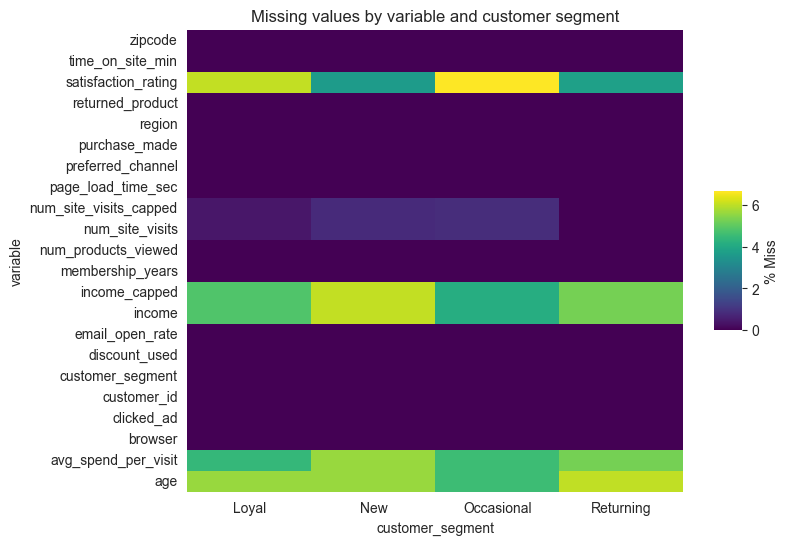

In [ ]:
# Create the heatmap based on the previous result
plt.figure(figsize=(8,6))
sns.heatmap(miss_pct, cmap='viridis', cbar_kws={"label": "% Miss", "shrink": 0.3, "aspect": 5})
plt.xlabel("customer_segment")
plt.ylabel("variable")
plt.title("Missing values by variable and customer segment")
plt.show()

From this graph, we can see if the missing values ​​are specific to any customer segment and analyze any possible pattern (e.g. **MAR**, **MNAR**).

- **Step 2: Test for Systematic Missingness**

    We created binary indicators for each variable with missing values. This allows us to subsequently evaluate whether the absence of data presents associations with other variables in the data set.

In [78]:
# Create binary indicators
df = df.assign(miss_age = lambda x: x["age"].isna(), 
               miss_income = lambda x: x["income_capped"].isna(), 
               miss_satisfaction = lambda x: x["satisfaction_rating"].isna(), 
               miss_avg_spend = lambda x: x["avg_spend_per_visit"].isna())

- **2A. Chi-square tests:**

    - **Missingness vs. `customer_segment` (categorical)**

    In R, the chisq.test() function can be used to apply the Pearson Chi-square test. For example:

    > ```r
    > chisq.test(table(df$miss_age, df$customer_segment))
    > ```

    In Python, work is not equal. To perform the test, it is first necessary to build a contingency table between the missing values ​​indicator variable (`miss_var`) and the `customer_segment` variable. Subsequently, the `chi2_contingency` function from the `stats` module of the SciPy library can be applied.

In [90]:
# Create a function similar to R to avoid repeating code
from scipy.stats import chi2_contingency

def chisq_test(miss_var, cust_segmt):
    contingency = pd.crosstab(miss_var, cust_segmt)
    chi2, p_value, dof, expected = chi2_contingency(contingency)

    return print("\nPearson's Chi-squared test", f"X-squared: {chi2.round(5)}", f"df: {dof}", f"p_value: {p_value.round(4)}", sep="\n")

In [91]:
# Check if missingness in age is related to customer segment
chisq_test(df['miss_age'], df['customer_segment'])


Pearson's Chi-squared test
X-squared: 0.55601
df: 3
p_value: 0.9064


In [92]:
# Check if missigness in income is related to customer segment
chisq_test(df['miss_income'], df['customer_segment'])


Pearson's Chi-squared test
X-squared: 0.94701
df: 3
p_value: 0.8141


In [93]:
# Same for satisfaction rating
chisq_test(df['miss_satisfaction'], df['customer_segment'])


Pearson's Chi-squared test
X-squared: 3.80136
df: 3
p_value: 0.2837


In [94]:
# Same for miss_avg_spend
chisq_test(df['miss_avg_spend'], df['customer_segment'])


Pearson's Chi-squared test
X-squared: 0.51654
df: 3
p_value: 0.9152


**Focusing on the p_value:**

> - If **p-value < 0.05**, missing values ​​depend on customer segment → **MAR**
> - If **p-value ≥ 0.05**, the association is not significant → possibly **MCAR**

- **2B. T-tests: Missingness vs. numeric predictors**

Evaluate whether the presence of missing values ​​in a variable is associated with significant differences in some numerical variable.

In R, the `t.test()` function can be used directly via a formula to compare both groups. For example:

>```r
># Are older customers more likely to skip income?
>t.test(age ~ miss_income, data = df)
>```

In Python, there is no equivalent syntax. To reproduce this analysis, it is first necessary to separate the numerical variable according to the groups defined by the missing values ​​indicator (**False** and **True**). Subsequently, a Welch Two Sample t-test can be applied using the Pingouin library and the corresponding averages for each group can be calculated.

In [95]:
import pingouin as pg

# Create the function similar to R
def t_test(var, miss_var, data):
    # Calculate means by missingness group
    means = data.groupby(miss_var, observed=False)[var].mean()

    # Calculate the Welch Two Sample t-test
    res_t = pg.ttest(x = data.loc[data[miss_var] == False, var], 
                     y = data.loc[data[miss_var] == True, var])
    print(res_t)
    print("\nSample estimates:")
    print(means.rename({False: "mean in group FALSE",
                        True: "mean in group TRUE"}))

In [96]:
# Are older customers more likely to skip income?
t_test('age', 'miss_income', data=df)

               T        dof alternative     p-val         CI95%   cohen-d  \
T-test  1.317992  52.195037   two-sided  0.193262  [-1.01, 4.9]  0.194525   

        BF10     power  
T-test  0.36  0.258954  

Sample estimates:
miss_income
mean in group FALSE    35.357461
mean in group TRUE     33.416667
Name: age, dtype: float64


In this case, the average age is compared between clients who have missing values ​​in income and those who do not.

In [44]:
# Do customers with missing avg spend differ in income
t_test('income_capped', 'miss_avg_spend',data=df)

               T        dof alternative     p-val              CI95%  \
T-test -0.236826  51.556513   two-sided  0.813731  [-259.07, 204.39]   

         cohen-d   BF10     power  
T-test  0.033544  0.166  0.055767  

Sample estimates:
miss_avg_spend
mean in group FALSE    2524.089228
mean in group TRUE     2551.432340
Name: income_capped, dtype: float64


In this case, the average income (`income_capped`) is compared between customers who have missing values ​​in `avg_spend_per_visit` and those who do not.

For both cases, a significant `p_value` indicates that there are statistically significant differences between both groups, suggesting that the missing values ​​may not occur at random.

**Results Summary**

| **Test** | **p-value** | **Interpretation** |
|------|--------:|----------------|
| `miss_age \~ customer_segment` | 0.906 | No association → likely **MCAR** |
| `miss_income \~ customer_segment` | 0.814 | No association → likely **MCAR** |
| `miss_satisfaction \~ customer_segment` | 0.284 | No association → likely **MCAR** |
| `miss_avg_spend \~ customer_segment` | 0.915 | No association → likely **MCAR** |
| `income_capped \~ miss_age` | 0.193 | No income difference → **MCAR** supported |
| `income_capped \~ miss_avg_spend` | 0.814 | No income difference → **MCAR** supported |

Based on the results obtained, **no statistically significant evidence of association is observed between the presence of missing values ​​and the analyzed variables**. This suggests that missing data could be consistent with random behavior, allowing simple imputation strategies such as mean, median, or mode to be considered.

### **6. Impute Missing Values**

In [45]:
# Calculate missingness and assign category
missing_summary = (df.isnull().mean()*100).rename_axis('variable').reset_index(name='pct_missing').sort_values('pct_missing',ascending=False)
missing_summary['category'] = np.select([missing_summary['pct_missing'] == 0,
                                        missing_summary['pct_missing'] > 30,
                                        (missing_summary['pct_missing'] > 10) & (missing_summary['pct_missing'] <= 30),
                                        (missing_summary['pct_missing'] > 0) & (missing_summary['pct_missing'] <= 10)],
                                        ["None (No action needed)",
                                        "High (Consider dropping)",
                                        "Moderate (Impute with caution)",
                                        "Low (Safe for imputation)"],
                                        default='Uncategorized')

missing_summary

,variable,pct_missing,category
2,age,5.494505,Low (Safe for imputation)
9,income,5.094905,Low (Safe for imputation)
20,income_capped,5.094905,Low (Safe for imputation)
6,satisfaction_rating,4.995005,Low (Safe for imputation)
10,avg_spend_per_visit,4.995005,Low (Safe for imputation)
3,num_site_visits,0.499500,Low (Safe for imputation)
21,num_site_visits_capped,0.499500,Low (Safe for imputation)
5,purchase_made,0.000000,None (No action needed)
1,region,0.000000,None (No action needed)
0,customer_id,0.000000,None (No action needed)


In [46]:
# Drop high-missing variables
vars_to_drop = missing_summary['variable'][missing_summary['category'] == 'High (Consider dropping)']
df.drop(columns=vars_to_drop)

,customer_id,region,age,num_site_visits,num_products_viewed,purchase_made,satisfaction_rating,customer_segment,preferred_channel,income,...,clicked_ad,returned_product,membership_years,zipcode,income_capped,num_site_visits_capped,miss_age,miss_income,miss_satisfaction,miss_avg_spend
0,1,Ancash,14.0,5.0,11,yes,unsatisfied,Occasional,Email,1815.52,...,1,yes,4,11001,1815.52,5.0,False,False,False,False
1,2,Piura,24.0,6.0,15,no,satisfied,New,Phone,3036.29,...,0,no,0,4001,3036.29,6.0,False,False,False,False
2,3,Piura,16.0,5.0,12,no,very unsatisfied,Occasional,In-store,3020.66,...,1,no,5,2001,3020.66,5.0,False,False,False,False
3,4,Lima,31.0,4.0,7,no,satisfied,Returning,Email,3569.71,...,1,no,5,13001,3569.71,4.0,False,False,False,False
4,5,La Libertad,35.0,4.0,7,no,unsatisfied,Loyal,Email,2352.62,...,1,no,3,13001,2352.62,4.0,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,997,Lima,10.0,6.0,18,no,satisfied,Occasional,SMS,1589.58,...,0,no,1,13001,1589.58,6.0,False,False,False,False
997,998,Cusco,43.0,6.0,8,no,unsatisfied,Loyal,Email,2691.20,...,1,yes,6,11001,2691.20,6.0,False,False,False,False
998,999,Lima,42.0,3.0,15,no,very satisfied,New,Email,3294.47,...,1,yes,3,2001,3294.47,3.0,False,False,False,False
999,1000,Lima,32.0,3.0,17,yes,unsatisfied,Occasional,Phone,2001.05,...,0,no,4,13001,2001.05,3.0,False,False,False,False


In [47]:
# Median for numeric variables
df['age'] = np.where(df['age'].isna(), df['age'].median(), df['age'])
df['income_capped'] = np.where(df['income_capped'].isna(), df['income_capped'].median(), df['income_capped'])
df['avg_spend_per_visit'] = np.where(df['avg_spend_per_visit'].isna(), df['avg_spend_per_visit'].median(), df['avg_spend_per_visit'])
df['num_site_visits_capped'] = np.where(df['num_site_visits_capped'].isna(), df['num_site_visits_capped'].median(), df['num_site_visits_capped'])

In [48]:
# Mode Imputation:
df['satisfaction_rating'] = np.where(df['satisfaction_rating'].isna(), 
                                     df['satisfaction_rating'].dropna().mode()[0], df['satisfaction_rating'])